# task 1: Optimize a continuous function using the genetic algorithm

In [1]:
from random import sample
import numpy as np
from sympy import *
import sympy as sy
import random
import pandas as pd
import matplotlib.pyplot as plt

## setting hyperparameter(user-defined)

In [2]:
# setting the max iteration
max_iter = 200

# number of variable
var_num = 1

# number of bit (usually it's 16)
bits = 16

# bound of the function 
bounds = (-5, 5)

# number of first generation
pop_num = 20

# number of next generation
next_generation = 20

# size of tournament selecting 
tournament_size = 16

# rate of crossover is realized
cross_rate = 0.8

# rate of mutation is realized
muta_rate = 0.1

# penalty factor for constraint
penalty_factor = 100000
epsilon = 0.1 # this is for preventing the value to cross the certain value under the constraint.

# setting objective function
x = symbols('x')
fx = 2 * x ** 4 - 10 * x ** 3 + 8 * x ** 2 + 5 * x


In [3]:
fx

2*x**4 - 10*x**3 + 8*x**2 + 5*x

## plot of the objective function 

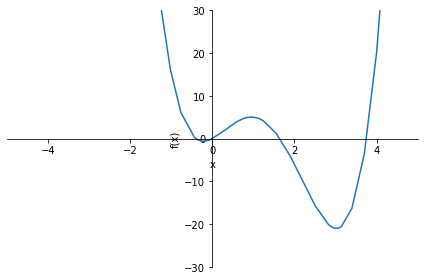

In [4]:
plot(fx, xlim = (-5, 5), ylim = (-30,30))

### function for making the bit-string

In [5]:
def bit_string(var_num, bits, pop_num):
    
    bitstring_list = []

    for _ in range(pop_num):
        
        bit_list = []
        
        for _ in range(var_num*bits):
            
            bit_list.append(str(random.randrange(0,2)))
            bitstring = "".join(bit_list)
            
        bitstring_list.append(bitstring)
    
    return bitstring_list

### function for decoding the bitstring to certain value within the interval

In [6]:
def decode(bit_list, bits, bounds):
    
    pop_list = []
    
    for i in range(len(bit_list)):
        
        decimal_val = int(bit_list[i], 2)
        
        min_val, max_val = bounds
        range_size = max_val - min_val
        scaled_val = min_val + (decimal_val / ((2 ** bits) - 1)) * range_size
             
        pop_list.append(scaled_val)
    
    pop_df = pd.DataFrame({'bitstring': bit_list,  # make it to dataframe so that we can preserve the bitstrings
                              'x': pop_list}) 
        
    return pop_df

### function for getting the function value

In [7]:
def pop_val(decoding, fx):
    
    pop_val = []
    pop_df = decoding
    
    for i in range(len(decoding)):
        pop_val.append(fx.subs([(x, pop_df['x'][i])]))
    
    pop_df['y'] = pop_val
    
    pop_df = pop_df.astype({ 'x' : 'float',
                            'y' : 'float'})
    
    fit_value = np.mean(pop_df.y)
    
    return pop_df, fit_value

### tournament selection

In [8]:
def tournament_selection(pop_df, tournament_size):
    tournament = pop_df.sample(n = tournament_size) 
    # If the size of the tournament is 16, there will be 8 greater DNAs left
    
    bit_list = []
    x_list = []
    y_list = []
    
    for num in range(0, int(tournament_size/2)):
        if tournament.iloc[2 * num,:]['y'] < tournament.iloc[2 * num + 1,:]['y']:  ## value which is smaller is better DNA
            bit_list.append(tournament.iloc[2 * num, :]['bitstring'])
            x_list.append(tournament.iloc[2 * num, :]['x'])
            y_list.append(tournament.iloc[2 * num, :]['y'])
        
        else:
            bit_list.append(tournament.iloc[2 * num + 1, :]['bitstring'])
            x_list.append(tournament.iloc[2 * num + 1, :]['x'])
            y_list.append(tournament.iloc[2 * num + 1, :]['y'])
    
    t_df = pd.DataFrame({'bitstring':bit_list,
                                'x': x_list,
                                'y': y_list})
    
    return t_df

### crossover

In [9]:
def crossover(t_df, cross_rate):
    
    crossover = t_df['bitstring'].sample(n = len(t_df))
    ## using Sampling, so order of t_df become random, that means first, second of t_df are selected randomly
    parent_1, parent_2 = crossover[0], crossover[1]
    
    offspring_1, offspring_2 = parent_1, parent_2
    
    # Choose a random crossover point
    if cross_rate > np.random.rand():
        crossover_point = random.randint(1, len(parent_1) - 2)
    
    # Create the offspring
        offspring_1 = parent_1[:crossover_point] + parent_2[crossover_point:]
        offspring_2 = parent_2[:crossover_point] + parent_1[crossover_point:]
    
    return offspring_1, offspring_2

### mutation

In [10]:
def mutation(t_df, bits, cross_m):
    t_df = t_df['bitstring'].sample(n = len(t_df))
    ## using Sampling, so order of t_df become random, that means first gene of t_df is also selected randomly
    bitstring = list(t_df[0])
    
    for i in range(bits):
        
        if cross_m > np.random.rand():
            if bitstring[i] == '0':
                bitstring[i] = '1'
            else: 
                bitstring[i] = '0'
     
    new_bitstring = "".join(bitstring)
    
    return new_bitstring

## Genetic algorithm which is made of gathering all of the functions defined before.

In [11]:
def genetic_algorithm():
    
    iteration = 0
    bit_list = bit_string(var_num, bits, pop_num) ## making the bitstring as number of populations
    prev_value = 0
    
    fit_list = []
    
    while iteration < max_iter:
        
        decoding = decode(bit_list, bits, bounds) ## decoding value (x - value)
            
        pop_df, fit_value = pop_val(decoding, fx) # y-value
        
        fit_list.append(fit_value)
        ## evaluate fitness function values
        if prev_value == fit_value:  ## Terminate if the previous value and the current value are the same
            break
        
        prev_value = fit_value # update the prev_value 
        
        t_df = tournament_selection(pop_df, tournament_size) # tournament selection
        
        new_list = []
    
        while len(new_list) < next_generation: ## Repeat until the next generation is number 'next_generation'
        
            new_list.extend([crossover(t_df, 0.8)[0], crossover(t_df, 0.8)[1]])
            new_list.append(mutation(t_df, bits, 0.2))
            
            if len(new_list) > next_generation:
                del new_list[-1]
        
        decoding_new = decode(new_list, bits, bounds)
        
        new_df, _ = pop_val(decoding_new, fx)
        
        all_df = pd.concat([pop_df, new_df], axis=0) ## Concatenate dataframe of the present generation and the next generation
        
        # Select only the top 50%
        all_df = all_df.sort_values(by = 'y', ascending = True)
        select_df = all_df[: int(len(all_df)/2)]
        
        bit_list = list(select_df.bitstring)
        
        iteration += 1
        
    print('number of iterations: {}'.format(iteration))
    
    return pop_df

In [12]:
pop_df = genetic_algorithm()

number of iterations: 19


In [13]:
pop_df

,bitstring,x,y
0,1100110101001011,3.019379,-21.009513
1,1100110101001011,3.019379,-21.009513
2,1100110101001011,3.019379,-21.009513
3,1100110101001011,3.019379,-21.009513
4,1100110101001011,3.019379,-21.009513
5,1100110101001011,3.019379,-21.009513
6,1100110101001011,3.019379,-21.009513
7,1100110101001011,3.019379,-21.009513
8,1100110101001011,3.019379,-21.009513
9,1100110101001011,3.019379,-21.009513


## With Constraints (x <= 2)

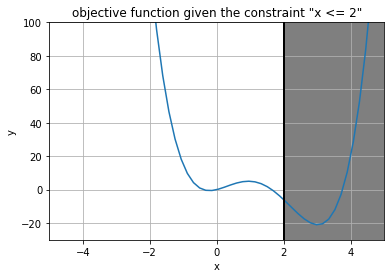

In [16]:
def f(xx):
    return 2*xx**4 - 10*xx**3 + 8*xx**2 + 5*xx

xx = np.linspace(-4, 5) 
yy = f(xx)               

plt.plot(xx, yy)
plt.xlabel('x')            
plt.ylabel('y')            
plt.vlines(2, -30, 100, color='black', linestyle='solid', linewidth=2)
plt.fill([2,2,5,5], [-30,100,100,-30], color='black', alpha=0.5)
plt.xlim([-5,5])
plt.ylim([-30, 100])
plt.grid()                  
plt.title('objective function given the constraint "x <= 2"')
plt.show()                 

### function for constraints penalty

In [17]:
def pop_val_penalty(decoding, fx, penalty_factor, epsilon):
    
    pop_val = []
    pop_df = decoding
    
    for i in range(len(decoding)):
        
        ## constraints x <= 2
        penalty_function = 0
        
        if pop_df['x'][i] > 2:
            
            ## Add epsilon to give a penalty that is even very close to 2 such as 2.000076.
            penalty_function = penalty_factor * (max(0, pop_df['x'][i] - (2 - epsilon)))**2
            pop_val.append(fx.subs([(x, pop_df['x'][i])]) + penalty_function) 
        
        else:
            pop_val.append(fx.subs([(x, pop_df['x'][i])]))
    
    pop_df['y'] = pop_val
    
    pop_df = pop_df.astype({ 'x' : 'float',
                             'y' : 'float'})
    
    fit_value = np.mean(pop_df.y)
    
    return pop_df, fit_value

In [18]:
def genetic_algorithm_constraint():
    
    iteration = 0
    bit_list = bit_string(var_num, bits, pop_num) ## making the bitstring as number of populations
    prev_value = 0
    
    fit_list = []
    
    while iteration < max_iter:
        
        decoding = decode(bit_list, bits, bounds) ## decoding value 
        
        # if x >= 2, get penalty
        pop_df, fit_value = pop_val_penalty(decoding, fx, penalty_factor, epsilon) 
        
        fit_list.append(fit_value)
        ## evaluate fitness function values
        if prev_value == fit_value:  
            break
        
        prev_value = fit_value # update
        
        t_df = tournament_selection(pop_df, tournament_size) # tournament 
        
        new_list = []
    
        while len(new_list) < next_generation: 
        
            new_list.extend([crossover(t_df, 0.8)[0], crossover(t_df, 0.8)[1]])
            new_list.append(mutation(t_df, bits, 0.2))
            
            if len(new_list) > next_generation:
                del new_list[-1]
        
        decoding_new = decode(new_list, bits, bounds)
        
        new_df, _ = pop_val(decoding_new, fx)
        
        all_df = pd.concat([pop_df, new_df], axis=0) 
            
        # selection
        all_df = all_df.sort_values(by = 'y', ascending = True)
        select_df = all_df[: int(len(all_df)/2)]
        
        bit_list = list(select_df.bitstring)
        
        iteration += 1
        
    print("number of iterations: {}".format(iteration))
    
    return pop_df

In [23]:
pop_df = genetic_algorithm_constraint()

number of iterations: 79


In [24]:
pop_df

,bitstring,x,y
0,1011001011111111,1.992142,-5.85094
1,1011001011111111,1.992142,-5.85094
2,1011001011111111,1.992142,-5.85094
3,1011001011111111,1.992142,-5.85094
4,1011001011111111,1.992142,-5.85094
5,1011001011111111,1.992142,-5.85094
6,1011001011111111,1.992142,-5.85094
7,1011001011111111,1.992142,-5.85094
8,1011001011111111,1.992142,-5.85094
9,1011001011111111,1.992142,-5.85094


## Occasionally, x exceeds 2

### After epsilon is added, check if there are situations where the mean of genes exceeds 2

In [236]:
for i in range(10):
    pop_df, _, _ = genetic_algorithm_constraint()
    
    print("index: {}, average of x: {}".format(i, pop_df.x[1]))

number of iterations: 17
index: 0, average of x: -0.2133974212252996
number of iterations: 31
index: 1, average of x: 1.8737315938048376
number of iterations: 14
index: 2, average of x: 1.989547570000763
number of iterations: 22
index: 3, average of x: 1.9968719005111772
number of iterations: 9
index: 4, average of x: 1.7142748149843587
number of iterations: 126
index: 5, average of x: 1.9921416037232014
number of iterations: 41
index: 6, average of x: 1.9993133440146487
number of iterations: 10
index: 7, average of x: -0.23323414969100487
number of iterations: 39
index: 8, average of x: 1.9994659342336156
number of iterations: 24
index: 9, average of x: 1.9884794384679942
